In [1]:
import control
import numpy as np
import matplotlib.pyplot as plt

import seisim.system
import seisim.predictor
import seisim.controller
import seisim.seisim


data = np.loadtxt("test_data/itmx_z_1441947618_64hz.txt")

t, ground_motion = data
dt = t[1] - t[0]

n_predict = int(1/dt)
n_control = int(1/dt)  # 1 seconds


s = control.tf("s")
wn = 7.85398163397
q = 1.11111111
tf = wn**2 / (s**2 + wn/q*s + wn**2)

system = seisim.system.System(tf, dt)

predictor = seisim.predictor.ConstantOrder(dt=dt, order=7, n_predict=n_predict)

controller = seisim.controller.MPCFF(
    model=None, n_predict=n_predict, n_control=n_control, predictor=predictor)

seisim = seisim.seisim.Seisim(system=system, controller=controller)

In [2]:
motion = seisim.simulate(t, ground_motion)

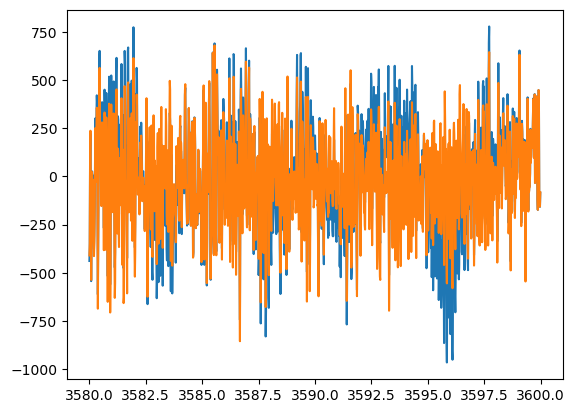

In [3]:
plt.plot(t[-1280:], ground_motion[-1280:])
plt.plot(t[-1280:], motion[-1280:])

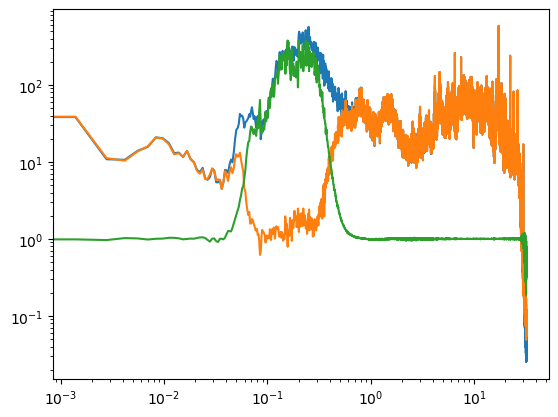

In [4]:
import scipy.signal


f, pyy = scipy.signal.welch(ground_motion, fs=1/dt, nperseg=int(len(ground_motion)/5))
f, pyy_ = scipy.signal.welch(motion, fs=1/dt, nperseg=int(len(motion)/5))

ayy = pyy**.5
ayy_ = pyy_**.5

suppression = ayy/ayy_
rmss = np.sqrt(np.trapezoid(suppression**2, f))
irmss = np.trapezoid(suppression, f)

plt.loglog(f, ayy)
plt.loglog(f, ayy_)

plt.loglog(f, ayy/ayy_)
# plt.axhline(rmss)
# plt.axhline(irmss, ls="--")
# plt.axhline(bl_sup, ls="--", color="red")
# plt.axvline(f1)
# plt.axvline(f2)

In [69]:
import scipy.optimize


def cost(args):
    f1_, f2_ = args
    if f1_ > f2_:
        f2 = f1_
        f1 = f2_
    else:
        f1 = f1_
        f2 = f2_
    mask = (f>f1) & (f<f2)
    f_ = f[mask]
    asd_ground_ = ayy[mask]
    asd_isolate_ = ayy_[mask]
    
    bl_ground = np.sqrt(np.trapezoid(asd_ground_**2, f_))
    bl_isolate = np.sqrt(np.trapezoid(asd_isolate_**2, f_))
    cost = bl_isolate/bl_ground
    return cost

res = scipy.optimize.minimize(cost, x0=(min(f), max(f)), method="nelder-mead")

In [10]:
f1_, f2_ = 0.05, 0.5
if f1_ > f2_:
    f2 = f1_
    f1 = f2_
else:
    f1 = f1_
    f2 = f2_
mask = (f>f1) & (f<f2)
ratio = ayy / ayy_
mask = ratio > 2
f_ = f[mask]
asd_ground_ = ayy[mask]
asd_isolate_ = ayy_[mask]

bl_ground = np.sqrt(np.trapezoid(asd_ground_**2, f_))
bl_isolate = np.sqrt(np.trapezoid(asd_isolate_**2, f_))
cost = bl_isolate/bl_ground
bl_sup = 1/cost

In [11]:
bl_sup

np.float64(22.34691127544858)

In [76]:
bl_sup

np.float64(23.396524802706352)

In [45]:
def test(key=None):
    # kwargs["key"] 
    print(key)
    if "key" not in kwargs.keys() or kwargs["key"] is None:
        kwargs["key"] = 2
    print(kwargs["key"])

In [51]:
kwargs = {"ke": 1}

test(**kwargs)


TypeError: test() got an unexpected keyword argument 'ke'

In [20]:
kwargs["a"]

KeyError: 'a'